# Credit Strategy Lite — Rule & Segment Impact Analysis

This notebook builds on the synthetic applicant dataset and rule-based decisioning
prototype. It focuses on three questions:

1. **Rule impact** – Which rules drive most declines or refers?
2. **Segment impact** – How do decisions differ across segments (Core / HighRisk / Value)?
3. **Policy scenario** – What happens if we relax the DTI cut-off from 0.55 to 0.60?

All analysis is kept at a *lite* level: deterministic rules, clear business logic,
and simple visuals suitable for risk / product stakeholders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("merged_data.csv")
df.head()


,app_id,income,dti,age,bureau_score,new_to_credit,recent_arrears,utilisation,hardship_flag,segment,rule_applicant,rule_behaviour,rule_policy,decision
0,1,33079.0,0.266,28,529.0,0,0,0.527,0,Value,pass,pass,decline_policy,decline
1,2,20661.0,0.240,31,655.0,0,0,0.581,0,Core,decline_affordability,pass,pass,decline
2,3,38664.0,0.372,30,646.0,0,0,1.038,0,Core,pass,refer_review,pass,refer
3,4,41324.0,0.350,36,688.0,0,1,0.552,0,Value,pass,refer_review,pass,refer
4,5,15020.0,0.151,31,711.0,0,0,0.791,0,Value,decline_affordability,pass,pass,decline


# 1. Rule Impact Analysis

In [6]:
# create flag（1 = happened）
df['flag_decline_affordability'] = (df['rule_applicant'] == 'decline_affordability').astype(int)
df['flag_decline_risk']          = (df['rule_applicant'] == 'decline_risk').astype(int)
df['flag_decline_policy']        = (df['rule_policy']    == 'decline_policy').astype(int)
df['flag_refer_behaviour']       = (df['rule_behaviour'] == 'refer_review').astype(int)

rule_flag_cols = [
    'flag_decline_affordability',
    'flag_decline_risk',
    'flag_decline_policy',
    'flag_refer_behaviour'
]


In [4]:
# final sample decision = decline 
df_decline = df[df['decision'] == 'decline'].copy()

# counts for decline 
rule_counts = df_decline[rule_flag_cols].sum().rename('decline_count')

total_declines = len(df_decline)

rule_impact = (
    rule_counts
    .to_frame()
    .assign(
        decline_pct=lambda x: (x['decline_count'] / total_declines * 100).round(1)
    )
    .reset_index()
    .rename(columns={'index': 'rule'})
    .sort_values('decline_count', ascending=False)
)

print(rule_impact)


                         rule  decline_count  decline_pct
0  flag_decline_affordability            678         98.4
3        flag_refer_behaviour            105         15.2
2         flag_decline_policy             14          2.0
1           flag_decline_risk              2          0.3


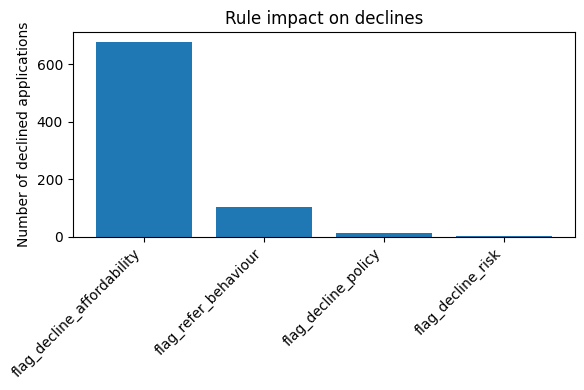

In [5]:
plt.figure(figsize=(6,4))
plt.bar(rule_impact['rule'], rule_impact['decline_count'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of declined applications")
plt.title("Rule impact on declines")
plt.tight_layout()
plt.savefig("rule_impact_declines.png", dpi=150)
plt.show()


# 2. Segment Impact: segment x decision mix

In [7]:
# numbers for segment × decision 
seg_decision_counts = (
    df
    .groupby(['segment', 'decision'])
    .size()
    .rename('count')
    .reset_index()
)

# mix
seg_decision_pivot = seg_decision_counts.pivot(
    index='segment',
    columns='decision',
    values='count'
).fillna(0)

#  segment%
seg_decision_prop = seg_decision_pivot.div(
    seg_decision_pivot.sum(axis=1),
    axis=0
).round(3)

print("Counts by segment × decision:")
print(seg_decision_pivot)

print("\nProportions by segment × decision:")
print(seg_decision_prop)


Counts by segment × decision:
decision  approve  decline  refer
segment                          
Core          606      360    117
HighRisk      176      111     36
Value         318      218     58

Proportions by segment × decision:
decision  approve  decline  refer
segment                          
Core        0.560    0.332  0.108
HighRisk    0.545    0.344  0.111
Value       0.535    0.367  0.098


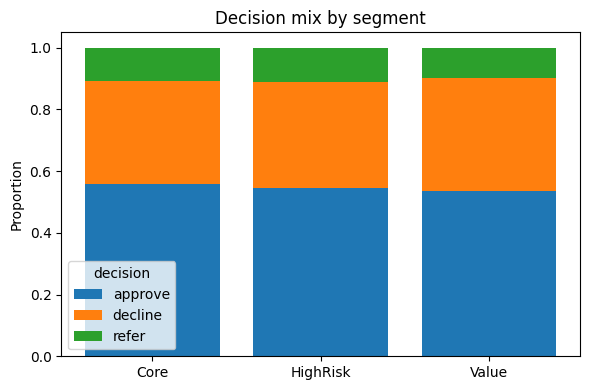

In [8]:
plt.figure(figsize=(6,4))

bottom = np.zeros(len(seg_decision_prop))
decisions = seg_decision_prop.columns

for d in decisions:
    plt.bar(
        seg_decision_prop.index,
        seg_decision_prop[d],
        bottom=bottom,
        label=d
    )
    bottom += seg_decision_prop[d].values

plt.ylabel("Proportion")
plt.title("Decision mix by segment")
plt.legend(title="decision")
plt.tight_layout()
plt.savefig("segment_decision_mix.png", dpi=150)
plt.show()


# 3. Policy Scenario Analysis（What-if）

In [9]:
def apply_decision_with_dti(df_in, dti_threshold=0.55):
    """
    given DTI, recalculate rule_applicant & decision
    Other rules（revenue、bureau、behaviour、policy）unchanged
    """
    df = df_in.copy()

    # ---- recaculate applicant rules ----
    df['rule_applicant_new'] = "pass"

    # affordability：income + DTI
    df.loc[df["income"] < 25000, "rule_applicant_new"] = "decline_affordability"
    df.loc[df["dti"] > dti_threshold, "rule_applicant_new"] = "decline_affordability"

    # risk decline：low bureau score
    df.loc[df["bureau_score"] < 500, "rule_applicant_new"] = "decline_risk"

    # ---- behaviour & policy rules：
    df['rule_behaviour_new'] = df['rule_behaviour']
    df['rule_policy_new']    = df['rule_policy']

    # ---- final decision ----
    def final_decision_row(row):
        if str(row["rule_applicant_new"]).startswith("decline"):
            return "decline"
        if str(row["rule_policy_new"]).startswith("decline"):
            return "decline"
        if str(row["rule_behaviour_new"]).startswith("refer"):
            return "refer"
        return "approve"

    df['decision_new'] = df.apply(final_decision_row, axis=1)
    return df


In [10]:
# baseline：orginal decision（DTI = 0.55）
base_summary = (
    df['decision']
    .value_counts(normalize=True)
    .rename('base_pct')
)

# New Scenario：DTI = 0.60
df_scenario = apply_decision_with_dti(df, dti_threshold=0.60)

scenario_summary = (
    df_scenario['decision_new']
    .value_counts(normalize=True)
    .rename('scenario_pct')
)

comparison = pd.concat([base_summary, scenario_summary], axis=1).fillna(0)
comparison = (comparison * 100).round(1)

print(comparison)


         base_pct  scenario_pct
approve      55.0          56.2
decline      34.4          33.2
refer        10.5          10.6


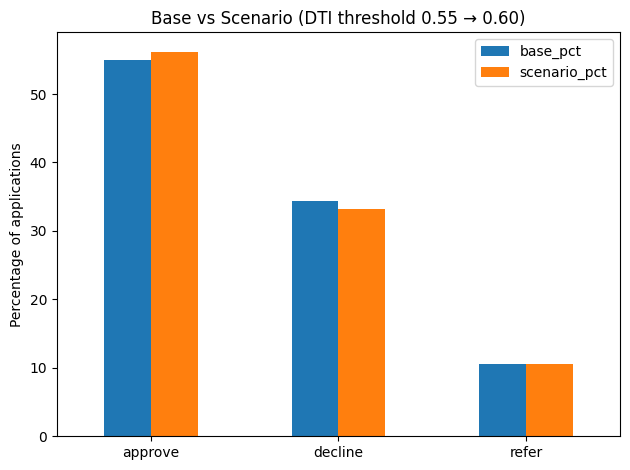

In [11]:
comparison.plot(kind='bar')
plt.ylabel("Percentage of applications")
plt.title("Base vs Scenario (DTI threshold 0.55 → 0.60)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("dti_policy_scenario.png", dpi=150)
plt.show()


Increasing the DTI threshold from 0.55 → 0.60 results in a +1.2pp improvement in approvals, driven by fewer affordability declines.

The change mainly impacts Core and Value segments, where applicants sitting just above the old DTI boundary now qualify.

The overall decision mix remains stable, with no structural changes to behavioural or policy declines.